# Homework 2 — Problem 2
## Next Character Prediction on Tiny Shakespeare: LSTM vs GRU
### Sequence Lengths: 20, 30, 50 · Hyperparameter Sweep Included




## Cell 1 — Imports & Device Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import math
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import Dataset, DataLoader

#  Device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: Tesla T4


## Cell 2 — Data Loading (Tiny Shakespeare)
*Provided data loader from course — extended to support variable sequence length and batch size.*


In [ ]:
#  Download dataset 
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
print("Downloading Tiny Shakespeare dataset...")
response = requests.get(url)
text = response.text
print(f"Downloaded {len(text):,} characters")

# Vocabulary 
chars       = sorted(list(set(text)))
vocab_size  = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
encoded_text = [char_to_int[ch] for ch in text]

print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {''.join(chars)}")


Downloaded 1,115,394 characters
Vocabulary size: 65 unique characters
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## Cell 3 — Dataset Class & DataLoader Factory

In [3]:
class CharDataset(Dataset):
    """Character-level sequence dataset (from course shakespeare-loader.py)."""
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets   = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


def build_loaders(seq_len, batch_size=128):
    """Build train/val DataLoaders for a given sequence length."""
    sequences, targets = [], []
    for i in range(len(encoded_text) - seq_len):
        sequences.append(encoded_text[i : i + seq_len])
        targets.append(encoded_text[i + seq_len])

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets   = torch.tensor(targets,   dtype=torch.long)

    dataset    = CharDataset(sequences, targets)
    train_size = int(len(dataset) * 0.8)
    test_size  = len(dataset) - train_size
    train_ds, test_ds = torch.utils.data.random_split(
        dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, shuffle=True,  batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  shuffle=False, batch_size=batch_size)
    return train_loader, test_loader


# Verify
tl, vl = build_loaders(seq_len=20)
print(f"seq_len=20 → train batches: {len(tl)}, val batches: {len(vl)}")


seq_len=20 → train batches: 6972, val batches: 1743


## Cell 4 — Model Definition (LSTM / GRU, configurable depth & width)

In [ ]:
class ShakespeareModel(nn.Module):
    """
    Configurable LSTM/GRU model for character-level language modelling.

    Args:
        rnn_type    : 'LSTM' | 'GRU'
        vocab_size  : number of unique characters
        embed_dim   : embedding dimension
        hidden_size : hidden units per RNN layer
        num_layers  : number of stacked RNN layers
        dropout     : dropout between layers (only active when num_layers > 1)
    """
    def __init__(self, rnn_type, vocab_size,
                 embed_dim=128, hidden_size=256,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.rnn_type    = rnn_type
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout   = nn.Dropout(dropout)

        rnn_cls = {"LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size  = embed_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        # Fully-connected head
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, vocab_size),
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))   # (B, T, embed_dim)
        out, _ = self.rnn(emb)                  # (B, T, hidden_size)
        return self.fc(out[:, -1, :])           # (B, vocab_size)


#  Helpers 
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_kb(model):
    return count_params(model) * 4 / 1024

# Quick check
for rnn_t in ["LSTM", "GRU"]:
    m = ShakespeareModel(rnn_t, vocab_size).to(device)
    print(f"{rnn_t}  params={count_params(m):,}  size={model_size_kb(m):.1f} KB")


LSTM  params=971,201  size=3793.8 KB
GRU  params=740,801  size=2893.8 KB


## Cell 5 — Training Engine

In [ ]:
def train_shakespeare(rnn_type, seq_len,
                      embed_dim=128, hidden_size=256,
                      num_layers=2, dropout=0.3,
                      epochs=10, lr=0.001, batch_size=128,
                      label=""):
    """
    Train one model config on Tiny Shakespeare.
    Returns a metrics dict including loss/accuracy curves and generated text.
    """
    train_loader, val_loader = build_loaders(seq_len, batch_size)

    model     = ShakespeareModel(rnn_type, vocab_size,
                                 embed_dim=embed_dim,
                                 hidden_size=hidden_size,
                                 num_layers=num_layers,
                                 dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    train_losses, val_losses, val_accs = [], [], []
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        #  Train 
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for seqs, tgts in train_loader:
            seqs, tgts = seqs.to(device), tgts.to(device)
            optimizer.zero_grad()
            out  = model(seqs)
            loss = criterion(out, tgts)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        scheduler.step()

        #  Validate
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for seqs, tgts in val_loader:
                seqs, tgts = seqs.to(device), tgts.to(device)
                out        = model(seqs)
                v_loss    += criterion(out, tgts).item()
                _, preds   = torch.max(out, 1)
                v_correct += (preds == tgts).sum().item()
                v_total   += tgts.size(0)

        avg_vloss = v_loss / len(val_loader)
        acc       = v_correct / v_total
        val_losses.append(avg_vloss)
        val_accs.append(acc)

        print(f"  [{label or rnn_type} | seq={seq_len}] "
              f"Epoch {epoch:2d}/{epochs}  "
              f"train_loss={avg_loss:.4f}  val_loss={avg_vloss:.4f}  "
              f"val_acc={acc:.4f}  perplexity={math.exp(avg_vloss):.2f}")

    elapsed = time.time() - t0

    return {
        "label"         : label or f"{rnn_type}_seq{seq_len}",
        "rnn_type"      : rnn_type,
        "seq_len"       : seq_len,
        "embed_dim"     : embed_dim,
        "hidden_size"   : hidden_size,
        "num_layers"    : num_layers,
        "train_losses"  : train_losses,
        "val_losses"    : val_losses,
        "val_accs"      : val_accs,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_acc"     : val_accs[-1],
        "perplexity"    : math.exp(val_losses[-1]),
        "train_time_s"  : elapsed,
        "num_params"    : count_params(model),
        "model_size_kb" : model_size_kb(model),
        "model"         : model,
    }

print("Training engine defined ✓")


Training engine defined ✓


## Cell 6 — Part A: Baseline Runs (seq_len = 20 and 30)
Train LSTM and GRU with the default architecture on sequence lengths 20 and 30.


In [6]:
EPOCHS_BASELINE = 10
baseline_results = []

for seq_len in [20, 30]:
    for rnn_type in ["LSTM", "GRU"]:
        print(f"\n{'='*60}")
        print(f"  Baseline: {rnn_type}  seq_len={seq_len}")
        print(f"{'='*60}")
        res = train_shakespeare(
            rnn_type   = rnn_type,
            seq_len    = seq_len,
            embed_dim  = 128,
            hidden_size= 256,
            num_layers = 2,
            epochs     = EPOCHS_BASELINE,
            label      = f"{rnn_type}_seq{seq_len}_baseline",
        )
        baseline_results.append(res)

print("\n✅ Baseline runs complete!")



  Baseline: LSTM  seq_len=20
  [LSTM_seq20_baseline | seq=20] Epoch  1/10  train_loss=1.9312  val_loss=1.5810  val_acc=0.5219  perplexity=4.86
  [LSTM_seq20_baseline | seq=20] Epoch  2/10  train_loss=1.6145  val_loss=1.4771  val_acc=0.5476  perplexity=4.38
  [LSTM_seq20_baseline | seq=20] Epoch  3/10  train_loss=1.5408  val_loss=1.4286  val_acc=0.5622  perplexity=4.17
  [LSTM_seq20_baseline | seq=20] Epoch  4/10  train_loss=1.5009  val_loss=1.4062  val_acc=0.5658  perplexity=4.08
  [LSTM_seq20_baseline | seq=20] Epoch  5/10  train_loss=1.4787  val_loss=1.3905  val_acc=0.5709  perplexity=4.02
  [LSTM_seq20_baseline | seq=20] Epoch  6/10  train_loss=1.4326  val_loss=1.3613  val_acc=0.5802  perplexity=3.90
  [LSTM_seq20_baseline | seq=20] Epoch  7/10  train_loss=1.4132  val_loss=1.3521  val_acc=0.5826  perplexity=3.87
  [LSTM_seq20_baseline | seq=20] Epoch  8/10  train_loss=1.4022  val_loss=1.3457  val_acc=0.5838  perplexity=3.84
  [LSTM_seq20_baseline | seq=20] Epoch  9/10  train_loss=1

## Cell 7 — Baseline Loss & Accuracy Plots (seq 20 vs 30)

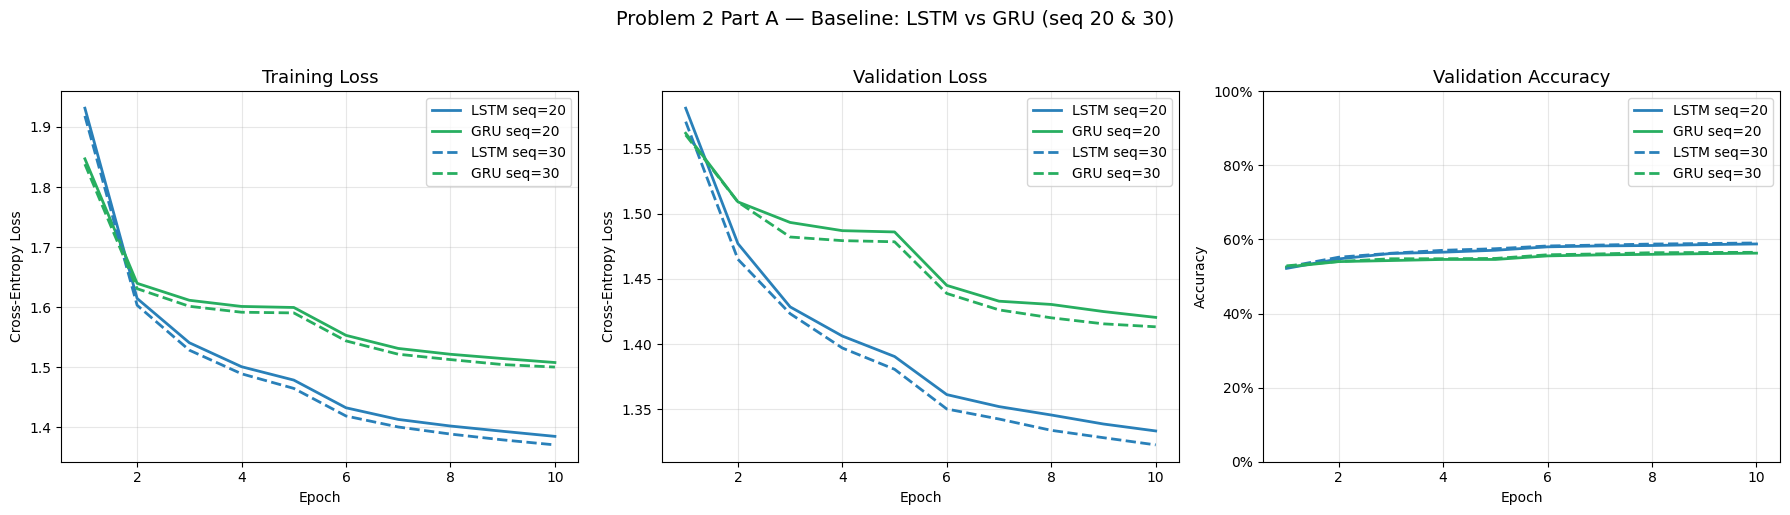

Saved → p2_baseline_curves.png


In [7]:
colors  = {"LSTM": "#2980b9", "GRU": "#27ae60"}
styles  = {20: "-", 30: "--"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss
ax = axes[0]
for r in baseline_results:
    ax.plot(range(1, len(r["train_losses"]) + 1),
            r["train_losses"],
            color=colors[r["rnn_type"]],
            linestyle=styles[r["seq_len"]],
            linewidth=2,
            label=f"{r['rnn_type']} seq={r['seq_len']}")
ax.set_title("Training Loss", fontsize=13)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Validation loss
ax = axes[1]
for r in baseline_results:
    ax.plot(range(1, len(r["val_losses"]) + 1),
            r["val_losses"],
            color=colors[r["rnn_type"]],
            linestyle=styles[r["seq_len"]],
            linewidth=2,
            label=f"{r['rnn_type']} seq={r['seq_len']}")
ax.set_title("Validation Loss", fontsize=13)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Validation accuracy
ax = axes[2]
for r in baseline_results:
    ax.plot(range(1, len(r["val_accs"]) + 1),
            r["val_accs"],
            color=colors[r["rnn_type"]],
            linestyle=styles[r["seq_len"]],
            linewidth=2,
            label=f"{r['rnn_type']} seq={r['seq_len']}")
ax.set_title("Validation Accuracy", fontsize=13)
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Problem 2 Part A — Baseline: LSTM vs GRU (seq 20 & 30)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("p2_baseline_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p2_baseline_curves.png")


## Cell 8 — Baseline Summary Table

In [8]:
print(f"{'Label':<30} {'Tr Loss':>8} {'Val Loss':>9} {'Val Acc':>8} "
      f"{'Perplexity':>11} {'Time(s)':>8} {'Params':>10} {'KB':>7}")
print("-" * 95)
for r in baseline_results:
    print(f"{r['label']:<30} {r['final_train_loss']:>8.4f} {r['final_val_loss']:>9.4f} "
          f"{r['final_acc']:>8.4f} {r['perplexity']:>11.2f} "
          f"{r['train_time_s']:>8.1f} {r['num_params']:>10,} {r['model_size_kb']:>7.1f}")


Label                           Tr Loss  Val Loss  Val Acc  Perplexity  Time(s)     Params      KB
-----------------------------------------------------------------------------------------------
LSTM_seq20_baseline              1.3850    1.3335   0.5879        3.79    554.8    971,201  3793.8
GRU_seq20_baseline               1.5079    1.4205   0.5631        4.14    465.3    740,801  2893.8
LSTM_seq30_baseline              1.3708    1.3228   0.5906        3.75    788.3    971,201  3793.8
GRU_seq30_baseline               1.5003    1.4133   0.5653        4.11    641.5    740,801  2893.8


## Cell 9 — Part B: Hyperparameter Sweep
Vary **hidden_size**, **num_layers**, and **embed_dim** to analyse their effect on accuracy,
training time, model size, and perplexity. Fixed seq_len=20 for comparability.


In [9]:
# Free all baseline models from GPU memory before sweep
import torch, gc
for r in baseline_results:
    del r["model"]
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed from baseline runs")
print("VRAM available:", round(torch.cuda.mem_get_info()[0]/1024**3, 2), "GB")

# Hyperparameter configurations to sweep
# Format: (label, rnn_type, embed_dim, hidden_size, num_layers, batch_size)
sweep_configs = [
    ("LSTM_h128_L2", "LSTM", 128, 128, 2, 64),
    ("LSTM_h256_L2", "LSTM", 128, 256, 2, 64),
    ("LSTM_h512_L2", "LSTM", 128, 512, 2, 32),
    ("LSTM_h256_L1", "LSTM", 128, 256, 1, 64),
    ("LSTM_h256_L3", "LSTM", 128, 256, 3, 32),
    ("GRU_h128_L2",  "GRU",  128, 128, 2, 64),
    ("GRU_h256_L2",  "GRU",  128, 256, 2, 64),
    ("GRU_h512_L2",  "GRU",  128, 512, 2, 32),
]

EPOCHS_SWEEP = 10
sweep_results = []

for (label, rnn_type, embed_dim, hidden_size, num_layers, batch_size) in sweep_configs:
    gc.collect()
    torch.cuda.empty_cache()
    sep = "=" * 60
    print(sep)
    print("  Sweep: " + label + "  (batch_size=" + str(batch_size) + ")")
    print(sep)
    res = train_shakespeare(
        rnn_type    = rnn_type,
        seq_len     = 20,
        embed_dim   = embed_dim,
        hidden_size = hidden_size,
        num_layers  = num_layers,
        epochs      = EPOCHS_SWEEP,
        batch_size  = batch_size,
        label       = label,
    )
    # Store metrics but immediately free the model from GPU
    del res["model"]
    sweep_results.append(res)
    gc.collect()
    torch.cuda.empty_cache()

print("Hyperparameter sweep complete!")


GPU memory freed from baseline runs
VRAM available: 14.36 GB
  Sweep: LSTM_h128_L2  (batch_size=64)
  [LSTM_h128_L2 | seq=20] Epoch  1/10  train_loss=2.0362  val_loss=1.7009  val_acc=0.4885  perplexity=5.48
  [LSTM_h128_L2 | seq=20] Epoch  2/10  train_loss=1.7762  val_loss=1.6018  val_acc=0.5147  perplexity=4.96
  [LSTM_h128_L2 | seq=20] Epoch  3/10  train_loss=1.7123  val_loss=1.5620  val_acc=0.5248  perplexity=4.77
  [LSTM_h128_L2 | seq=20] Epoch  4/10  train_loss=1.6780  val_loss=1.5343  val_acc=0.5334  perplexity=4.64
  [LSTM_h128_L2 | seq=20] Epoch  5/10  train_loss=1.6563  val_loss=1.5205  val_acc=0.5382  perplexity=4.57
  [LSTM_h128_L2 | seq=20] Epoch  6/10  train_loss=1.6156  val_loss=1.4865  val_acc=0.5461  perplexity=4.42
  [LSTM_h128_L2 | seq=20] Epoch  7/10  train_loss=1.5992  val_loss=1.4782  val_acc=0.5477  perplexity=4.39
  [LSTM_h128_L2 | seq=20] Epoch  8/10  train_loss=1.5895  val_loss=1.4699  val_acc=0.5502  perplexity=4.35
  [LSTM_h128_L2 | seq=20] Epoch  9/10  train

## Cell 10 — Sweep Results: Loss Curves

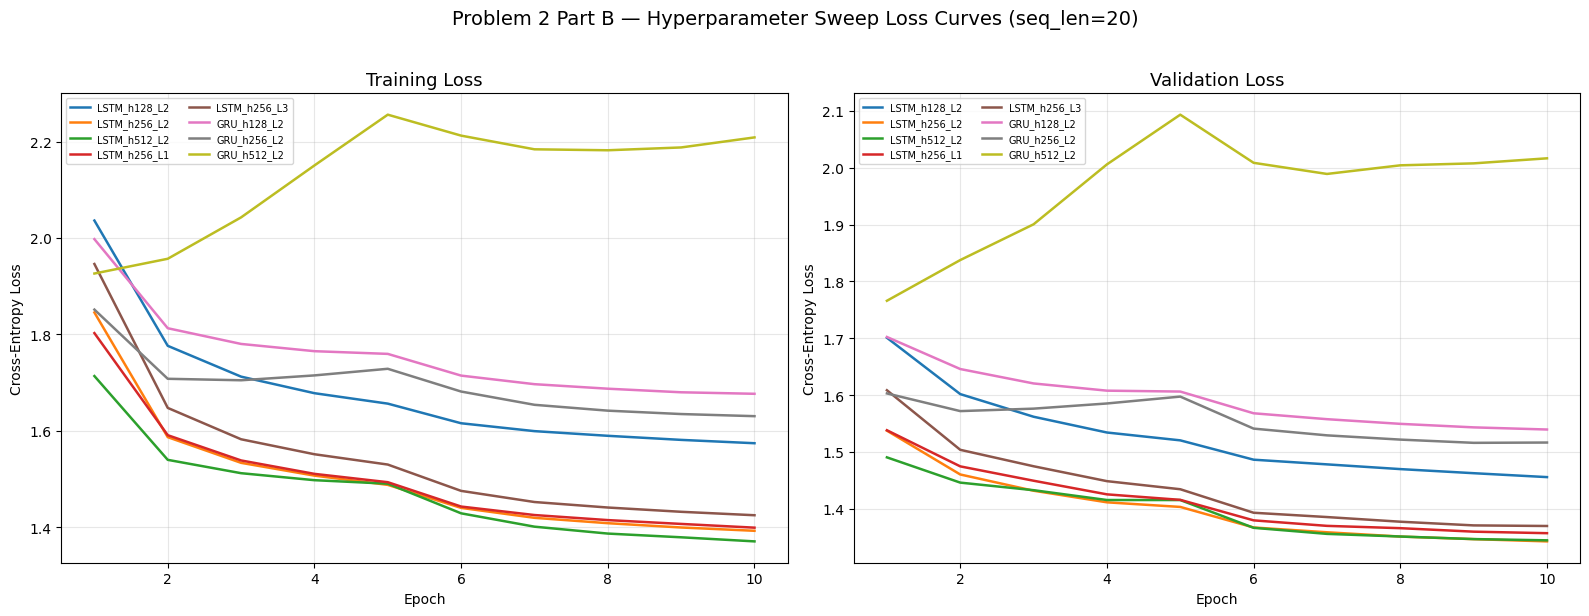

Saved → p2_sweep_loss.png


In [10]:
import itertools

cmap   = plt.get_cmap("tab10")
n      = len(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, r in enumerate(sweep_results):
    c = cmap(i / n)
    axes[0].plot(range(1, EPOCHS_SWEEP + 1), r["train_losses"],
                 label=r["label"], color=c, linewidth=1.8)
    axes[1].plot(range(1, EPOCHS_SWEEP + 1), r["val_losses"],
                 label=r["label"], color=c, linewidth=1.8)

for ax, title in zip(axes, ["Training Loss", "Validation Loss"]):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle("Problem 2 Part B — Hyperparameter Sweep Loss Curves (seq_len=20)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("p2_sweep_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p2_sweep_loss.png")


## Cell 11 — Sweep Comparison: Accuracy · Perplexity · Time · Size

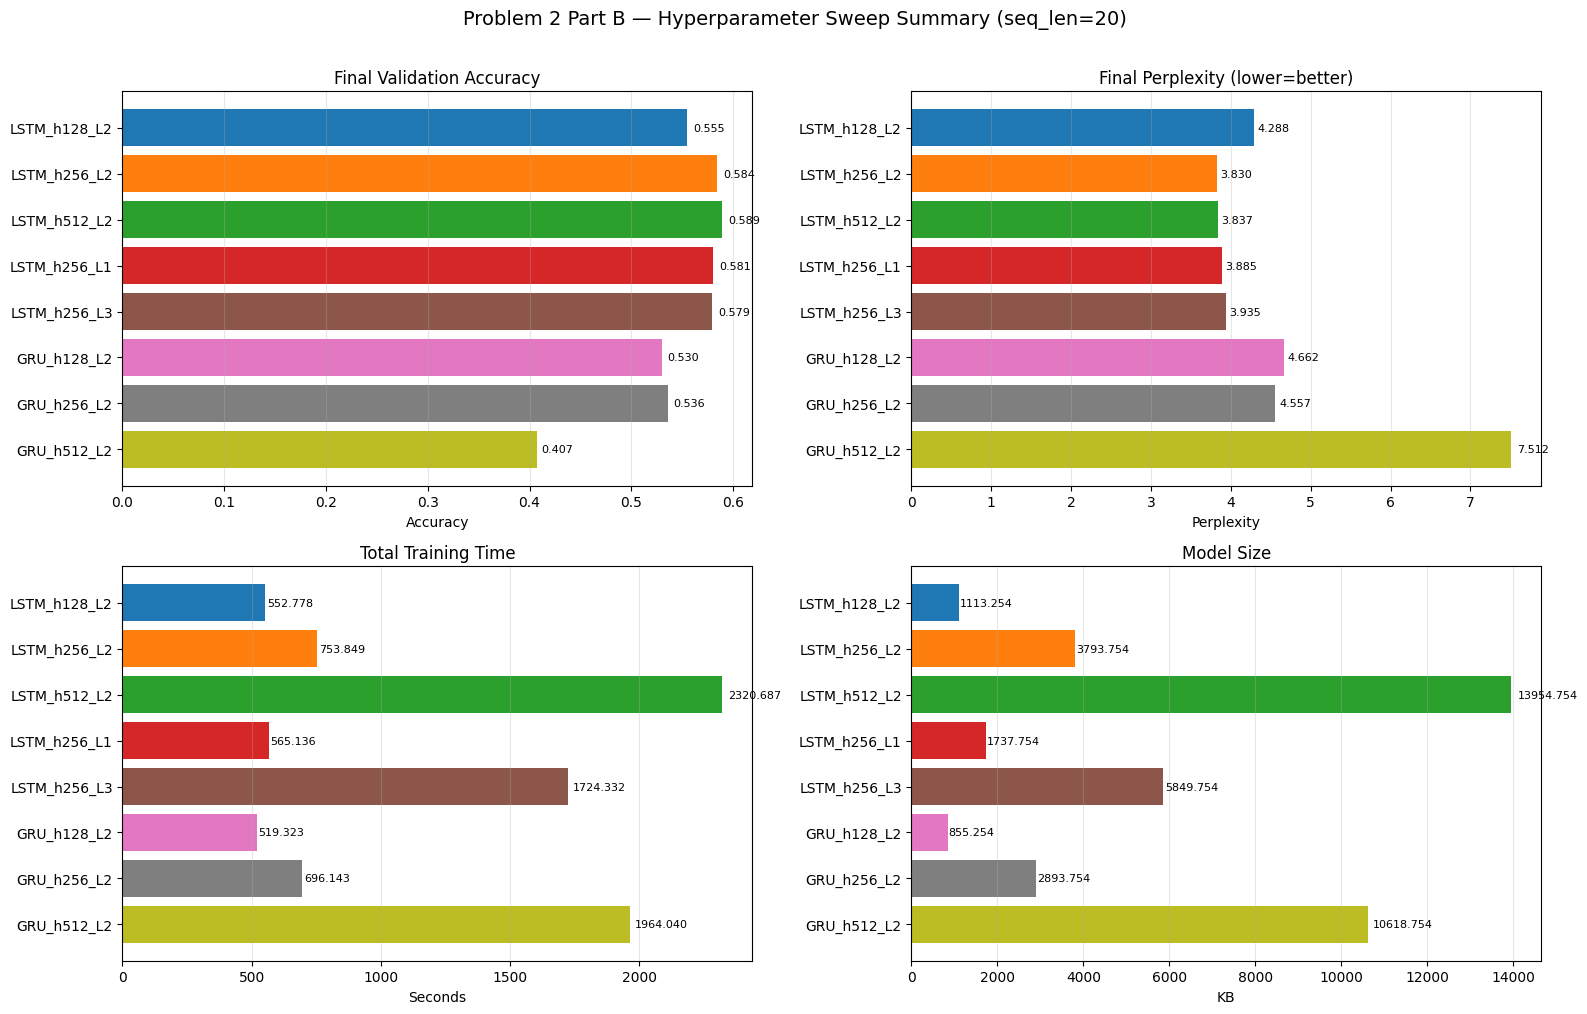

Saved → p2_sweep_bars.png


In [11]:
labels_s     = [r["label"]          for r in sweep_results]
accs_s       = [r["final_acc"]      for r in sweep_results]
perp_s       = [r["perplexity"]     for r in sweep_results]
times_s      = [r["train_time_s"]   for r in sweep_results]
sizes_s      = [r["model_size_kb"]  for r in sweep_results]
bar_colors   = [cmap(i / n) for i in range(n)]

xs = range(n)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def hbar(ax, vals, title, xlabel):
    bars = ax.barh(labels_s, vals, color=bar_colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=8)

hbar(axes[0,0], accs_s,   "Final Validation Accuracy",  "Accuracy")
hbar(axes[0,1], perp_s,   "Final Perplexity (lower=better)", "Perplexity")
hbar(axes[1,0], times_s,  "Total Training Time",        "Seconds")
hbar(axes[1,1], sizes_s,  "Model Size",                 "KB")

plt.suptitle("Problem 2 Part B — Hyperparameter Sweep Summary (seq_len=20)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("p2_sweep_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p2_sweep_bars.png")


## Cell 12 — Sweep Summary Table

In [12]:
print(f"{'Label':<22} {'H':>5} {'L':>3} {'Val Acc':>8} {'Perplexity':>11} "
      f"{'Time(s)':>8} {'Params':>10} {'KB':>7}")
print("-" * 78)
for r in sweep_results:
    print(f"{r['label']:<22} {r['hidden_size']:>5} {r['num_layers']:>3} "
          f"{r['final_acc']:>8.4f} {r['perplexity']:>11.2f} "
          f"{r['train_time_s']:>8.1f} {r['num_params']:>10,} {r['model_size_kb']:>7.1f}")


Label                      H   L  Val Acc  Perplexity  Time(s)     Params      KB
------------------------------------------------------------------------------
LSTM_h128_L2             128   2   0.5551        4.29    552.8    284,993  1113.3
LSTM_h256_L2             256   2   0.5843        3.83    753.8    971,201  3793.8
LSTM_h512_L2             512   2   0.5895        3.84   2320.7  3,572,417 13954.8
LSTM_h256_L1             256   1   0.5806        3.89    565.1    444,865  1737.8
LSTM_h256_L3             256   3   0.5795        3.93   1724.3  1,497,537  5849.8
GRU_h128_L2              128   2   0.5303        4.66    519.3    218,945   855.3
GRU_h256_L2              256   2   0.5360        4.56    696.1    740,801  2893.8
GRU_h512_L2              512   2   0.4070        7.51   1964.0  2,718,401 10618.8


## Cell 13 — Part C: Extended Sequence Length (seq_len = 50)
Training LSTM and GRU with seq_len=50 to observe the effect of longer context windows.


In [13]:
EPOCHS_50 = 10
seq50_results = []

for rnn_type in ["LSTM", "GRU"]:
    print(f"\n{'='*60}")
    print(f"  seq_len=50: {rnn_type}")
    print(f"{'='*60}")
    res = train_shakespeare(
        rnn_type    = rnn_type,
        seq_len     = 50,
        embed_dim   = 128,
        hidden_size = 256,
        num_layers  = 2,
        epochs      = EPOCHS_50,
        label       = f"{rnn_type}_seq50",
    )
    seq50_results.append(res)

print("\n✅ seq_len=50 runs complete!")



  seq_len=50: LSTM
  [LSTM_seq50 | seq=50] Epoch  1/10  train_loss=1.9243  val_loss=1.5664  val_acc=0.5241  perplexity=4.79
  [LSTM_seq50 | seq=50] Epoch  2/10  train_loss=1.6000  val_loss=1.4617  val_acc=0.5507  perplexity=4.31
  [LSTM_seq50 | seq=50] Epoch  3/10  train_loss=1.5249  val_loss=1.4216  val_acc=0.5626  perplexity=4.14
  [LSTM_seq50 | seq=50] Epoch  4/10  train_loss=1.4845  val_loss=1.3917  val_acc=0.5714  perplexity=4.02
  [LSTM_seq50 | seq=50] Epoch  5/10  train_loss=1.4590  val_loss=1.3758  val_acc=0.5755  perplexity=3.96
  [LSTM_seq50 | seq=50] Epoch  6/10  train_loss=1.4118  val_loss=1.3462  val_acc=0.5844  perplexity=3.84
  [LSTM_seq50 | seq=50] Epoch  7/10  train_loss=1.3928  val_loss=1.3352  val_acc=0.5865  perplexity=3.80
  [LSTM_seq50 | seq=50] Epoch  8/10  train_loss=1.3811  val_loss=1.3278  val_acc=0.5899  perplexity=3.77
  [LSTM_seq50 | seq=50] Epoch  9/10  train_loss=1.3711  val_loss=1.3227  val_acc=0.5912  perplexity=3.75
  [LSTM_seq50 | seq=50] Epoch 10/10

## Cell 14 — seq_len Comparison: 20 vs 30 vs 50

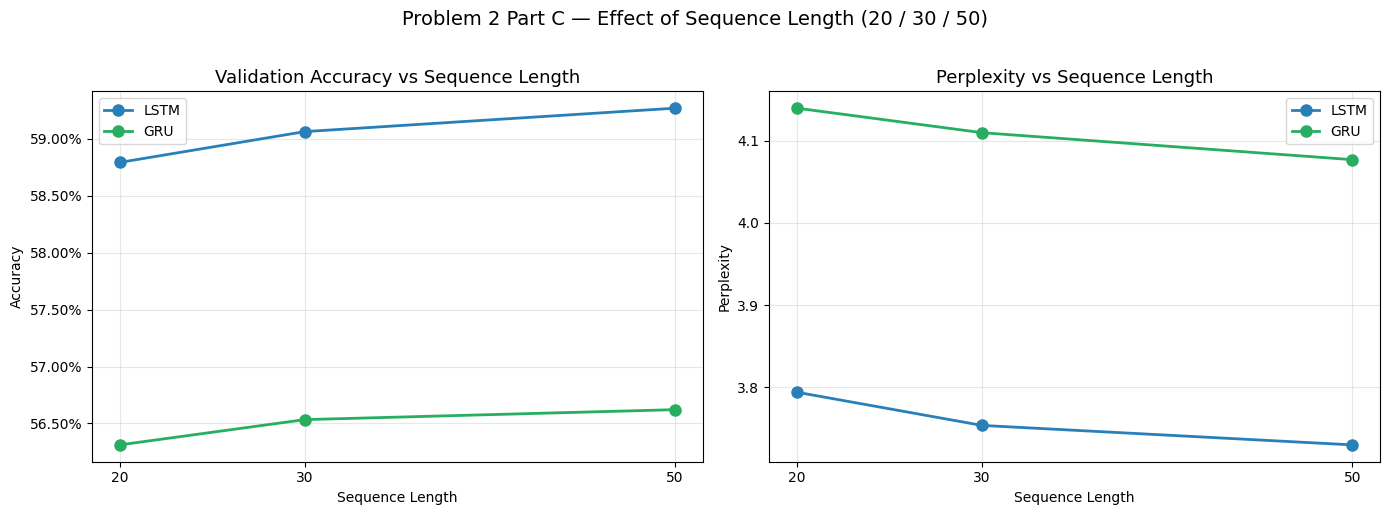

Saved → p2_seqlen_comparison.png


In [14]:
all_seqlen_results = baseline_results + seq50_results

# Group by model type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seq_lengths_all = [20, 30, 50]
colors_m = {"LSTM": "#2980b9", "GRU": "#27ae60"}
markers  = {20: "o", 30: "s", 50: "^"}

for rnn_type in ["LSTM", "GRU"]:
    rtype_results = [r for r in all_seqlen_results if r["rnn_type"] == rnn_type]
    rtype_results.sort(key=lambda x: x["seq_len"])
    seqs  = [r["seq_len"]    for r in rtype_results]
    accs  = [r["final_acc"]  for r in rtype_results]
    perps = [r["perplexity"] for r in rtype_results]

    axes[0].plot(seqs, accs,  marker="o", color=colors_m[rnn_type],
                 linewidth=2, markersize=8, label=rnn_type)
    axes[1].plot(seqs, perps, marker="o", color=colors_m[rnn_type],
                 linewidth=2, markersize=8, label=rnn_type)

for ax, (title, ylabel) in zip(axes, [
    ("Validation Accuracy vs Sequence Length",  "Accuracy"),
    ("Perplexity vs Sequence Length",           "Perplexity"),
]):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel(ylabel)
    ax.set_xticks([20, 30, 50])
    ax.legend(); ax.grid(True, alpha=0.3)

axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.suptitle("Problem 2 Part C — Effect of Sequence Length (20 / 30 / 50)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("p2_seqlen_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p2_seqlen_comparison.png")


## Cell 15 — Text Generation (Inference)

In [ ]:
def generate_text(model, seed_text, seq_len, num_chars=200, temperature=1.0):
    """
    Generate text character-by-character using a trained model.

    Args:
        temperature : >1 = more random, <1 = more deterministic
    """
    model.eval()
    # Pad or trim seed to exactly seq_len
    if len(seed_text) < seq_len:
        seed_text = seed_text.rjust(seq_len)
    seed_text = seed_text[-seq_len:]

    generated = seed_text
    inp = [char_to_int.get(c, 0) for c in seed_text]

    with torch.no_grad():
        for _ in range(num_chars):
            x    = torch.tensor([inp[-seq_len:]], dtype=torch.long).to(device)
            out  = model(x)                         # (1, vocab_size)
            # Temperature scaling
            probs = torch.softmax(out / temperature, dim=-1).squeeze()
            next_ix = torch.multinomial(probs, 1).item()
            inp.append(next_ix)
            generated += int_to_char[next_ix]

    return generated


#  Generate from each seq50 model 
seed = "To be, or not to be"
print("=" * 65)
for r in seq50_results:
    gen = generate_text(r["model"], seed, seq_len=50, num_chars=300, temperature=0.8)
    print(f"\n--- {r['rnn_type']} (seq_len=50, temp=0.8) ---")
    print(gen)
    print()



--- LSTM (seq_len=50, temp=0.8) ---
                               To be, or not to be:
I'll not kind that have would at want was that hew
Into my fortunes, to me should be since.

BENVOLIO:
There is my brothers had tell a barren:
My lord, to this blood bow out of this will;
But she shall lays them supposed bid us
We tell thee like you: I will these encounter that
I have bear the cro


--- GRU (seq_len=50, temp=0.8) ---
                               To be, or not to be
murder'd to any gate, what shall live me dement.

POLIXENES:
So the world, and hows to dile request set the
embraince is thy issued the order put a partice,
Were you seen my love and done my counsel,
And thou art thou hast that thou won and very
Out a tertain of the man for your chaste, the man
per



## Cell 16 — Complete Results Summary Table (All Parts)

In [16]:
all_p2_results = baseline_results + seq50_results

print(f"{'Label':<28} {'SeqLen':>7} {'Val Acc':>8} {'Perplexity':>11} "
      f"{'Time(s)':>8} {'Params':>10} {'KB':>7}")
print("-" * 85)
for r in all_p2_results:
    print(f"{r['label']:<28} {r['seq_len']:>7} {r['final_acc']:>8.4f} "
          f"{r['perplexity']:>11.2f} {r['train_time_s']:>8.1f} "
          f"{r['num_params']:>10,} {r['model_size_kb']:>7.1f}")


Label                         SeqLen  Val Acc  Perplexity  Time(s)     Params      KB
-------------------------------------------------------------------------------------
LSTM_seq20_baseline               20   0.5879        3.79    554.8    971,201  3793.8
GRU_seq20_baseline                20   0.5631        4.14    465.3    740,801  2893.8
LSTM_seq30_baseline               30   0.5906        3.75    788.3    971,201  3793.8
GRU_seq30_baseline                30   0.5653        4.11    641.5    740,801  2893.8
LSTM_seq50                        50   0.5927        3.73   1267.1    971,201  3793.8
GRU_seq50                         50   0.5662        4.08   1026.3    740,801  2893.8


In [1]:
import subprocess
import sys
import os

notebook_path = __vsc_ipynb_file__  # VS Code gives this automatically

# Convert to HTML first
result = subprocess.run(
    [sys.executable, "-m", "nbconvert", "--to", "html", notebook_path],
    capture_output=True, text=True
)

if result.returncode == 0:
    html_path = notebook_path.replace(".ipynb", ".html")
    print(f"✅ HTML saved: {html_path}")
    print("Now open that file in Chrome and Ctrl+P → Save as PDF")
else:
    print("❌ Error:", result.stderr)

✅ HTML saved: c:\Users\jacob\Downloads\hw2problem2_final.html
Now open that file in Chrome and Ctrl+P → Save as PDF
